### Loading the dataset
This is the newly feature engineered dataset from `feature_engineering.ipynb`

In [1]:
import pandas as pd
import numpy as np

# loading the dataset into dataframe
df = pd.read_csv('../data/features.csv')

df.head()

,timestamp,server_id,cpu_percent,memory_percent,disk_io,is_anomaly,anomaly_type,cpu_percent_roll_mean_5,cpu_percent_roll_standard_deviation_5,cpu_percent_roll_mean_10,...,hour,day_of_week,cpu_percent_rate_of_change,memory_percent_rate_of_change,disk_io_rate_of_change,server_type_batch_worker,server_type_cache,server_type_database,server_type_load_balancer,server_type_web
0,2025-01-01 00:05:00,web_1,19.308678,25.694752,43.981028,0,normal,20.896125,2.244988,20.896125,...,0,2,-3.174892,2.419824,-19.470143,0,0,0,0,1
1,2025-01-01 00:10:00,web_1,23.238443,36.885905,57.091144,0,normal,21.676897,2.085378,21.676897,...,0,2,3.929764,11.191153,13.110116,0,0,0,0,1
2,2025-01-01 00:15:00,web_1,27.615149,35.100183,51.622232,0,normal,23.161460,3.422705,23.161460,...,0,2,4.376707,-1.785722,-5.468912,0,0,0,0,1
3,2025-01-01 00:20:00,web_1,18.829233,28.184342,33.647097,0,normal,22.295015,3.541161,22.295015,...,0,2,-8.785916,-6.915841,-17.975135,0,0,0,0,1
4,2025-01-01 00:25:00,web_1,18.829315,34.272010,40.813835,0,normal,21.564164,3.855648,21.717398,...,0,2,0.000082,6.087668,7.166738,0,0,0,0,1


### Dropping columns 
Dropping the following:
- `timestamp`: raw datetime, not usuable
- `server_id`: just use the lable or identifier

### Training the model using Isolation forest: full 39 feature set

In [2]:
y = df['is_anomaly']
# `is_anomaly`: this is the ground truth label, and shoulnd't be used during training
X = df.drop(columns=["timestamp","server_id","is_anomaly","anomaly_type"])

print(X.shape)
print(X.columns)
print(y.value_counts())


(90705, 40)
Index(['cpu_percent', 'memory_percent', 'disk_io', 'cpu_percent_roll_mean_5',
       'cpu_percent_roll_standard_deviation_5', 'cpu_percent_roll_mean_10',
       'cpu_percent_roll_standard_deviation_10', 'cpu_percent_roll_mean_30',
       'cpu_percent_roll_standard_deviation_30', 'memory_percent_roll_mean_5',
       'memory_percent_roll_standard_deviation_5',
       'memory_percent_roll_mean_10',
       'memory_percent_roll_standard_deviation_10',
       'memory_percent_roll_mean_30',
       'memory_percent_roll_standard_deviation_30', 'disk_io_roll_mean_5',
       'disk_io_roll_standard_deviation_5', 'disk_io_roll_mean_10',
       'disk_io_roll_standard_deviation_10', 'disk_io_roll_mean_30',
       'disk_io_roll_standard_deviation_30', 'cpu_percent_zscore_5',
       'cpu_percent_zscore_10', 'cpu_percent_zscore_30',
       'memory_percent_zscore_5', 'memory_percent_zscore_10',
       'memory_percent_zscore_30', 'disk_io_zscore_5', 'disk_io_zscore_10',
       'disk_io_zscore_

In [3]:
# calculate the contamination rate 
contamination_rate = y.sum() / len(y)
print(contamination_rate)

0.0018631828454881208


In [4]:
# fit the model with the dataframe
from sklearn.ensemble import IsolationForest
clf = IsolationForest(contamination=contamination_rate, random_state=42).fit(X)

In [5]:
predictions = clf.predict(X)
print(pd.Series(predictions).value_counts())

 1    90536
-1      169
Name: count, dtype: int64


### Classification report 
`Precision` - How many of the true positves flagged by the model is accurate 
$$Precision = \frac{\text{True Positives (TP)}}{\text{True Positives (TP)} + \text{False Positives (FP)}}$$
`Recall` - How many actually true positives did the model catch 
$$Recall = \frac{\text{True Positives (TP)}}{\text{True Positives (TP)} + \text{False Negatives (FN)}}$$
`F1-score1` - This is the harmonic mean of the recall and precison
$$F_1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

The precison, recall and f1-score (for this first round of training the model) for class `1` is extremley low, meaning the model is not catching anything almost correctly.

In [6]:
# check the models predictions
from sklearn.metrics import classification_report

# if predictions == -1, this would output True
# .astype will convert True to 1
predictions_binary = (predictions == -1).astype(int) # converts -1 to 1

# classification report on the predicitons
classification_report_full_set = classification_report(y, predictions_binary)
print(classification_report_full_set)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     90536
           1       0.01      0.01      0.01       169

    accuracy                           1.00     90705
   macro avg       0.50      0.50      0.50     90705
weighted avg       1.00      1.00      1.00     90705



### Diagnosing the failure
Using `decision_function` to check whether the true anomalies show up as clearly negative
scores, or whether they blend into the normal range.

What was found:
- There is a measurable difference — anomaly scores are lower on average (`0.147` vs `0.215`)
- The two distributions overlap a lot, meaning individual rows are often not distinguishable
  from one another

This suggests the model is learning something real, but the signal is weak.

In [7]:
df['anomaly_score'] = clf.decision_function(X)
print(df[df['is_anomaly'] == 1]['anomaly_score'].describe())
print(df[df['is_anomaly'] == 0]['anomaly_score'].describe())

count    169.000000
mean       0.146996
std        0.060214
min       -0.010724
25%        0.103588
50%        0.145595
75%        0.204743
max        0.249969
Name: anomaly_score, dtype: float64
count    90536.000000
mean         0.214645
std          0.050040
min         -0.036571
25%          0.198521
50%          0.228508
75%          0.248534
max          0.282165
Name: anomaly_score, dtype: float64


#### Investigating how extreme the anomalies are
Looking into `web_1` to compare the `anomaly_score`'s for a non-anomaly and anomaly, to see if there is a spike

What was found:
- The anomaly_scores didn't reflect the anomalies clearly, showing no spike or dip
- The anomalies blended into the rest of the data

               timestamp  is_anomaly  anomaly_score
2699 2025-01-10 09:00:00           0       0.127946
2700 2025-01-10 09:05:00           0       0.107189
2701 2025-01-10 09:10:00           0       0.108402
2702 2025-01-10 09:15:00           0       0.142912
2703 2025-01-10 09:20:00           0       0.152238
2704 2025-01-10 09:25:00           0       0.160946
2705 2025-01-10 09:30:00           0       0.168770
2706 2025-01-10 09:35:00           0       0.160433
2707 2025-01-10 09:40:00           0       0.184736
2708 2025-01-10 09:45:00           0       0.179123
2709 2025-01-10 09:50:00           0       0.184616
2710 2025-01-10 09:55:00           0       0.158526
2711 2025-01-10 10:00:00           1       0.139463
2712 2025-01-10 10:05:00           1       0.110142
2713 2025-01-10 10:10:00           1       0.141171
2714 2025-01-10 10:15:00           1       0.117126
2715 2025-01-10 10:20:00           1       0.153577
2716 2025-01-10 10:25:00           1       0.131236
2717 2025-01

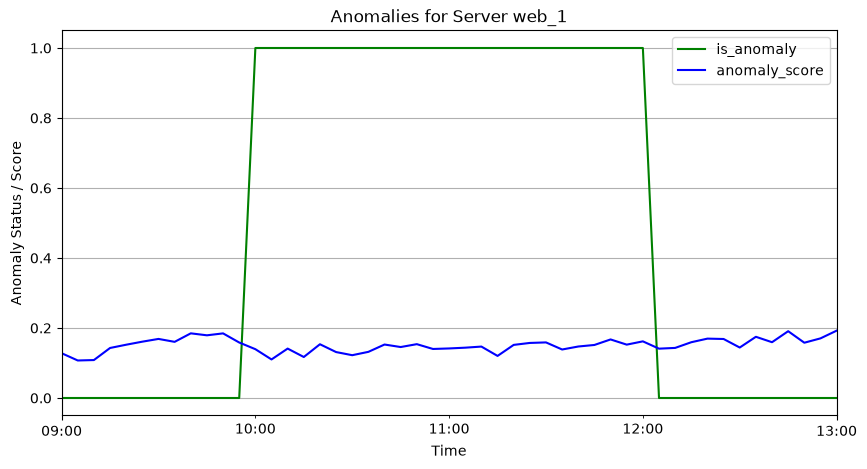

In [8]:
import matplotlib.pyplot as plt\

df['timestamp'] = pd.to_datetime(df['timestamp'])

start_time = '2025-01-10 09:00:00'
end_time = '2025-01-10 13:00:00'

condition = (df['server_id'] == 'web_1') & (df['timestamp'].between(start_time, end_time))

plot_data = df[condition][['timestamp','is_anomaly', 'anomaly_score']]
print(plot_data)

plot_data = plot_data.set_index('timestamp') # make timestamp the index of the dataframe

plot_data.plot(figsize=(10, 5), kind='line',color=['green','blue'], title='Anomalies for Server web_1')
plt.ylabel('Anomaly Status / Score')
plt.xlabel('Time')
plt.grid(True)
plt.show()

In [9]:
# check the cpu_percent anomalies for web_1 are present
# confirm if that some data is missing
df[(df['server_id'] == 'web_1') & (df['is_anomaly'] == 1)]['cpu_percent'].describe()

count     25.000000
mean      94.096024
std        4.667200
min       83.458590
25%       92.199874
50%       95.118247
75%       97.395977
max      100.000000
Name: cpu_percent, dtype: float64

### Hypothesis 1: The feature set is too large. 
As isolation forest builds trees based on randomly selected features, with so many features and where only a handful of them hold a strong signal of an anomaly, there is a chance that the model is splitting on irrelevant features which don't relate to the particular anomaly.

**Next experiment**: Train the model using a smaller feature set, using more targeted features.

In [10]:
X_small = df[['cpu_percent','cpu_percent_zscore_5','cpu_percent_zscore_10','cpu_percent_zscore_30','server_type_batch_worker','server_type_cache','server_type_database','server_type_load_balancer','server_type_web']]
 
# cpu percent only, contamination rate
cpu_percent_anomalies = df.loc[(df['anomaly_type'] == 'cpu_anomaly') & (df['is_anomaly'] == 1)]
print(f'Number of anomalies: {len(cpu_percent_anomalies)}')
contamination_rate_smaller_set = len(cpu_percent_anomalies) / len(df)
print(f'Contamination rate for CPU anomalies: {contamination_rate_smaller_set}')

# train the model usint the new feature set
clf = IsolationForest(contamination=contamination_rate_smaller_set, random_state=42).fit(X_small)

Number of anomalies: 109
Contamination rate for CPU anomalies: 0.001201697811587013


In [12]:
# Predict using the trained model
predictions_small_set = clf.predict(X_small)
print(pd.Series(predictions_small_set).value_counts())

predictions_binary_small_set = (predictions_small_set == -1).astype(int)

y_cpu_only = (df['anomaly_type'] == 'cpu_anomaly').astype(int)
# classification report on the predicitons
classification_report_small_set = classification_report(y_cpu_only, predictions_binary_small_set)
print(classification_report_small_set)

 1    90596
-1      109
Name: count, dtype: int64
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     90596
           1       0.00      0.00      0.00       109

    accuracy                           1.00     90705
   macro avg       0.50      0.50      0.50     90705
weighted avg       1.00      1.00      1.00     90705



From the above experiment, it is clear even modelling on a smaller featrue set doesn't seem to imporove the model. However it has highlighted that the raw data values need to be looked into a little more.

The raw `cpu_percent` values need to be considered, for `batch_worker` server type the cpu_percent is 0 for majority of the day. This means a huge chunk of the whole dataset is sitting around 0. Isolation forest is based on random splits of randomly chosen features, the raw values are incomparable compared to other values within the dataset. Specifcially for `cpu_percent`, `web_1` server raw values can't be comapred to the `batch_worker`'s (constant 0) raw values 

And below we see that the `precision`,`recall` and `f1-score` are still 0.00. This shows that the number of features doesn't affect the models perfomance detecting anomalies.

In [13]:
X_zscore = df[['cpu_percent_zscore_5', 'cpu_percent_zscore_10', 'cpu_percent_zscore_30']]

print(f'Number of anomalies: {len(cpu_percent_anomalies)}')
contamination_rate_zscore_set = len(cpu_percent_anomalies) / len(df)
print(f'Contamination rate for CPU anomalies: {contamination_rate_zscore_set}')

# train the model usint the new feature set
clf = IsolationForest(contamination=contamination_rate_zscore_set, random_state=42).fit(X_zscore)

Number of anomalies: 109
Contamination rate for CPU anomalies: 0.001201697811587013


In [14]:
# Predict using the trained model
predictions_zscore_set = clf.predict(X_zscore)
print(pd.Series(predictions_zscore_set).value_counts())

predictions_binary_zscore_set = (predictions_zscore_set == -1).astype(int)

# classification report on the predicitons
classification_report_zscore_set = classification_report(y_cpu_only, predictions_binary_zscore_set)
print(classification_report_zscore_set)

 1    90597
-1      108
Name: count, dtype: int64
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     90596
           1       0.00      0.00      0.00       109

    accuracy                           1.00     90705
   macro avg       0.50      0.50      0.50     90705
weighted avg       1.00      1.00      1.00     90705



In [26]:
anomalies = df[df['is_anomaly'] == 1]
pd.set_option('display.max_rows', None)
print(
    anomalies[
        ['server_id', 'anomaly_type', 'anomaly_score']
    ].sort_values('anomaly_score')
)
pd.reset_option('display.max_rows')

             server_id     anomaly_type  anomaly_score
87861   batch_worker_3  disk_io_anomaly      -0.010724
87857   batch_worker_3  disk_io_anomaly      -0.003609
83818   batch_worker_2   memory_anomaly       0.017671
87858   batch_worker_3  disk_io_anomaly       0.019736
87859   batch_worker_3  disk_io_anomaly       0.022749
87860   batch_worker_3  disk_io_anomaly       0.026307
83821   batch_worker_2   memory_anomaly       0.029428
83820   batch_worker_2   memory_anomaly       0.033433
76351   batch_worker_1      cpu_anomaly       0.041333
83819   batch_worker_2   memory_anomaly       0.044402
29786       database_2      cpu_anomaly       0.055102
76353   batch_worker_1      cpu_anomaly       0.059992
29787       database_2      cpu_anomaly       0.062348
76354   batch_worker_1      cpu_anomaly       0.062826
29792       database_2      cpu_anomaly       0.062870
76352   batch_worker_1      cpu_anomaly       0.066611
76355   batch_worker_1      cpu_anomaly       0.067686
76356   ba

### Hypothesis 2: Data heterogeneity across server types

With 5 structurally different server types (15 servers total) sharing a single Isolation
Forest, the model's notion of "normal" is being shaped by all five distributions at once —
in particular, `batch_worker`'s mostly-zero, briefly-spiking pattern appears to dominate the
overall score scale, based on the sorted anomaly-score investigation above. Including
`server_type` as a one-hot feature was an attempt to let the model condition on this
difference, but the experiments above (full feature set, reduced feature set, Z-score-only
feature set) all produced near-identical, near-zero precision/recall for the anomaly class —
suggesting the model isn't reliably learning to separate "normal" per server type from a
single shared training pass.

**Next experiment:** train 5 separate Isolation Forest models, one per `server_type`, each
learning "normal" from only its own server type's data. Evaluate each model against the
anomalies belonging to its own server type, rather than scoring all 15 servers with one
shared model and threshold.